#**AI-BASED DEMAND FORECASTING AND LOW-STOCK PREDICTION FOR DAIRY INVENTORY MANAGEMENT SYSTEMS**

###**STEP 1 - IMPORT  REQUIRED LIBRARIES AND LOAD THE DATASET**
This step imports the required libraries and loads the dataset into a DataFrame.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings

# Machine learning imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_squared_error, mean_absolute_error,
    roc_curve, roc_auc_score
)

# Suppress warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv('/content/dairy_dataset.csv',
                 parse_dates=['Production Date', 'Expiration Date'])

# Preview first five rows
df.head()

,Location,Total Land Area (acres),Number of Cows,Farm Size,Date,Product ID,Product Name,Brand,Quantity (liters/kg),Price per Unit,...,Production Date,Expiration Date,Quantity Sold (liters/kg),Price per Unit (sold),Approx. Total Revenue(INR),Customer Location,Sales Channel,Quantity in Stock (liters/kg),Minimum Stock Threshold (liters/kg),Reorder Quantity (liters/kg)
0,Telangana,310.84,96,Medium,2022-02-17,5,Ice Cream,Dodla Dairy,222.40,85.72,...,2021-12-27,2022-01-21,7,82.24,575.68,Madhya Pradesh,Wholesale,215,19.55,64.03
1,Uttar Pradesh,19.19,44,Large,2021-12-01,1,Milk,Amul,687.48,42.61,...,2021-10-03,2021-10-25,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
2,Tamil Nadu,581.69,24,Medium,2022-02-28,4,Yogurt,Dodla Dairy,503.48,36.50,...,2022-01-14,2022-02-13,256,33.81,8655.36,Madhya Pradesh,Online,247,15.10,140.83
3,Telangana,908.00,89,Small,2019-06-09,3,Cheese,Britannia Industries,823.36,26.52,...,2019-05-15,2019-07-26,601,28.92,17380.92,Rajasthan,Online,222,74.50,57.68
4,Maharashtra,861.95,21,Medium,2020-12-14,8,Buttermilk,Mother Dairy,147.77,83.85,...,2020-10-17,2020-10-28,145,83.07,12045.15,Jharkhand,Retail,2,76.02,33.40


###**STEP 2 - CONVERT DATE COLUMNS TO DATETIME FORMAT**
This step converts the selected date fields into datetime format.

In [ ]:
# Convert selected date columns to datetime format
date_cols = ['Date', 'Production Date', 'Expiration Date']

# Convert each column to datetime
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Display updated data types to confirm conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4325 entries, 0 to 4324
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Location                             4325 non-null   object        
 1   Total Land Area (acres)              4325 non-null   float64       
 2   Number of Cows                       4325 non-null   int64         
 3   Farm Size                            4325 non-null   object        
 4   Date                                 4325 non-null   datetime64[ns]
 5   Product ID                           4325 non-null   int64         
 6   Product Name                         4325 non-null   object        
 7   Brand                                4325 non-null   object        
 8   Quantity (liters/kg)                 4325 non-null   float64       
 9   Price per Unit                       4325 non-null   float64       
 10  Total Value 

The date-related columns were successfully converted to datetime format, ensuring they can be used for time-series analysis and feature engineering.

###**STEP 3 - CREATE LOW-STOCK TARGET VARIABLE**
This step creates a binary target variable indicating whether stock falls below the minimum threshold.

In [ ]:
# Create binary low-stock label (1 = below threshold, 0 = sufficient stock)
df['LowStock'] = (
    df['Quantity in Stock (liters/kg)'] < df['Minimum Stock Threshold (liters/kg)']
).astype(int)

# Check the class distribution
df['LowStock'].value_counts()

,count
LowStock,
0,3407
1,918


The LowStock target variable was created to identify products falling below the minimum stock threshold. The class distribution shows an imbalance, with more observations labeled as sufficiently stocked than low stock.

##**MODEL 1: SALES FORECASTING (TIME SERIES)**
This model predicts daily demand using a 7-day moving average to support production planning.

###**STEP 4 - PREPARE DAILY TIME SERIES DATA**
This step prepares the daily demand values and applies a 7-day moving average for forecasting.

In [ ]:
# Group data by date and calculate total daily demand
daily = df.groupby('Date')['Quantity (liters/kg)'].sum().reset_index()

# Sort by date to ensure chronological order
daily = daily.sort_values('Date')

# Create a 7-day moving average (shifted by 1 day to prevent data leakage)
daily['ma_7'] = daily['Quantity (liters/kg)'].rolling(7).mean().shift(1)

# Remove rows where the moving average could not be calculated
ts = daily.dropna()

# Preview the prepared time series data
ts.head()

,Date,Quantity (liters/kg),ma_7
7,2019-01-08,1352.62,1916.787143
8,2019-01-09,3231.49,1596.447143
9,2019-01-11,2905.26,1847.428571
10,2019-01-12,137.95,2097.875714
11,2019-01-13,1639.05,1943.772857


The dataset was aggregated by date to generate total daily demand, and a 7-day moving average was calculated to smooth fluctuations and capture trend patterns. The moving average was shifted by one day to avoid data leakage, and rows without valid rolling values were removed. The resulting time-series data (ts) is now ready for forecasting.

###**STEP 5 - TRAIN-TEST SPLIT FOR TIME SERIES MODEL**
This step splits the time-series data into training and testing sets, ensuring the model learns from past values and is evaluated on recent data.

In [ ]:
# Determine index for an 80/20 time series split
split_index = int(len(ts) * 0.8)

# Split into training (first 80%) and test (last 20%)
train_ts = ts.iloc[:split_index]
test_ts = ts.iloc[split_index:]

# Extract true and predicted values for the test set
y_true_ts = test_ts['Quantity (liters/kg)']
y_pred_ts = test_ts['ma_7']

# Display the train/test sample counts
print(f"Training samples: {len(train_ts)}")
print(f"Test samples: {len(test_ts)}")

Training samples: 1016
Test samples: 255


The time series data was split using an 80/20 ratio, with earlier observations assigned to the training set and the most recent data reserved for testing. This ensures proper chronological structure and prevents data leakage during forecasting evaluation.

###**STEP 6 - EVALUATE TIME-SERIES MODEL (MAE & RMSE)**
This step evaluates the forecasting performance of the moving average model using MAE and RMSE.

In [ ]:
# Calculate MAE and RMSE
mae_ts = mean_absolute_error(y_true_ts, y_pred_ts)
rmse_ts = np.sqrt(mean_squared_error(y_true_ts, y_pred_ts))

# Display formatted results
print(f"Mean Absolute Error (MAE): {mae_ts:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ts:.2f}")

Mean Absolute Error (MAE): 843.73
Root Mean Squared Error (RMSE): 1045.50


Model performance was evaluated using MAE and RMSE. The error values indicate how closely the 7-day moving average forecast aligns with actual demand. Lower values represent better predictive accuracy, although additional model tuning or alternative forecasting methods may further reduce error.

###**STEP 7 - PLOT ACTUAL VS PREDICTED DAILY DEMAND**
This step visualizes the actual daily demand compared to the predicted values from the 7-day moving average model.

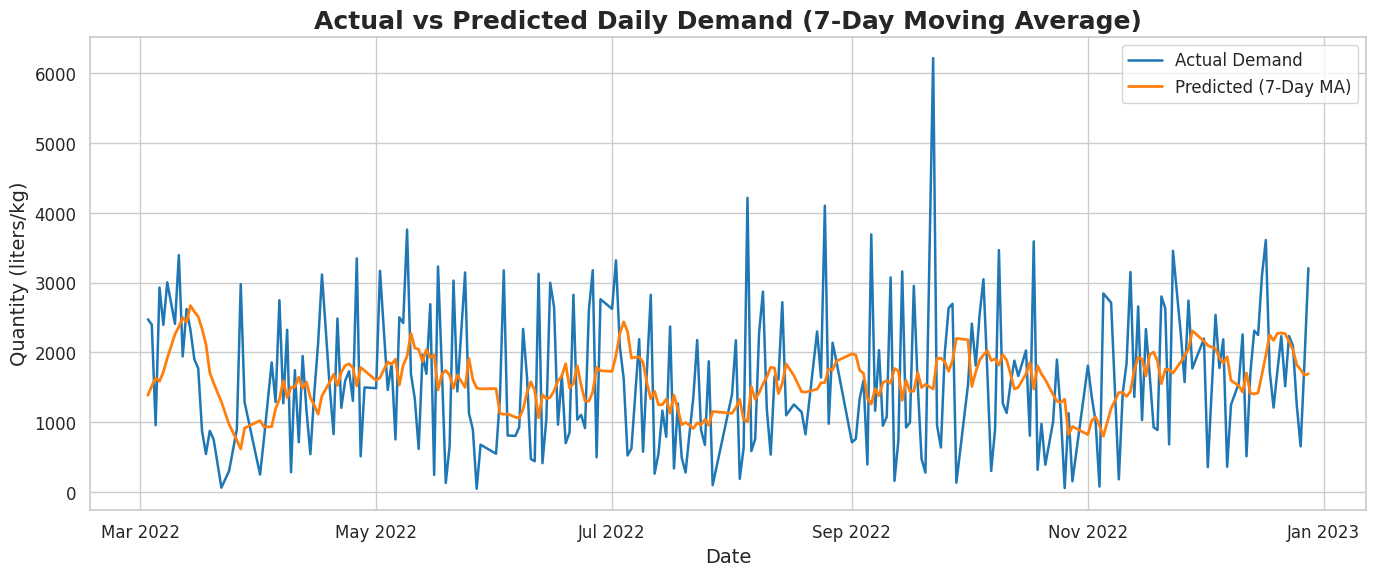

In [ ]:
# Set up the figure
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid", font_scale=1.2)

# Plot the actual demand (test period)
plt.plot(test_ts['Date'], y_true_ts,
         label="Actual Demand",
         linewidth=1.8,
         color="#1f77b4")

# Plot the predicted demand (7-day moving average, test period)
plt.plot(test_ts['Date'], y_pred_ts,
         label="Predicted (7-Day MA)",
         linewidth=2.0,
         color="#ff7f0e")

# Format the chart
plt.title("Actual vs Predicted Daily Demand (7-Day Moving Average)", fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Quantity (liters/kg)", fontsize=14)

# Format x-axis dates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Final layout formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

The demand forecast uses the most recent 7-day moving average to predict short-term demand. This provides a simple, stable forecast based on recent trends.

###**STEP 8 - DEFINE FEATURES FOR LOW-STOCK CLASSIFICATION**
This step selects numerical and categorical features from the dataset to prepare inputs for the low-stock classification model.

In [ ]:
# Target variable
target = 'LowStock'

# Numeric features
numeric = [
    'Total Land Area (acres)',
    'Number of Cows',
    'Quantity (liters/kg)',
    'Price per Unit',
    'Shelf Life (days)',
    'Quantity Sold (liters/kg)',
    'Price per Unit (sold)',
    'Approx. Total Revenue(INR)',
    'Quantity in Stock (liters/kg)',
    'Minimum Stock Threshold (liters/kg)',
    'Reorder Quantity (liters/kg)'
]

# Categorical features
categorical = [
    'Location',
    'Farm Size',
    'Product Name',
    'Brand',
    'Storage Condition',
    'Customer Location',
    'Sales Channel'
]

# Define feature set (X) and target (y)
X = df[numeric + categorical]
y = df[target]

Relevant numerical and categorical features were selected to build the low-stock classification model. The feature matrix (X) contains both business and operational attributes, while the LowStock column serves as the target variable (y).

###**STEP 9 - PREPROCESS FEATURES FOR CLASSIFICATION**
This step scales numerical features and applies one-hot encoding to categorical features using a ColumnTransformer.

In [ ]:
# Scale numeric features and apply one-hot encoding to categorical features
numeric_transform = StandardScaler()
categorical_transform = OneHotEncoder(handle_unknown='ignore')

# Combine preprocessing steps for numeric and categorical data
preprocess = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transform, numeric),
        ('categorical', categorical_transform, categorical)
    ]
)

The preprocessing pipeline standardizes numerical features and applies one-hot encoding to categorical inputs. This ensures all variables are in a suitable format for the classification model, preventing numeric scale bias and enabling categorical features to be used effectively during training.

###**STEP 10 - BUILD LOGISTIC REGRESSION PIPELINE**
This step combines preprocessing and logistic regression into a single pipeline model.

In [ ]:
# Build the logistic regression pipeline
clf = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
)

The logistic regression model was integrated into a pipeline along with the preprocessing steps. The class_weight='balanced' parameter helps address the class imbalance by giving more weight to low-stock samples during training.

###**STEP 11 - TRAIN-TEST SPLIT FOR CLASSIFICATION MODEL**
This step splits the data into training and testing sets using stratified sampling to ensure the class distribution is balanced between both sets.

In [ ]:
# Split the data into training and testing sets (stratified sampling)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the split sizes and class balance
print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set size: 3460
Test set size: 865

Class distribution in training set:
LowStock
0    0.787861
1    0.212139
Name: proportion, dtype: float64

Class distribution in test set:
LowStock
0    0.787283
1    0.212717
Name: proportion, dtype: float64


The dataset was split into training and testing sets using stratified sampling to preserve the original class distribution. The class balance remains consistent across both sets, which helps ensure fair model evaluation without bias toward the majority class.

###**STEP 12 - TRAIN LOGISTIC REGRESSION MODEL AND MAKE PREDICTIONS**
This step trains the logistic regression classification model on the training data and generates predictions for the test set.

In [ ]:
# Train the logistic regression model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Compare the first 10 predicted values with the actual values
print(f"Predicted: {list(y_pred[:10])}")
print(f"Actual:    {list(y_test[:10])}")

Predicted: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]
Actual:    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


Comparing a sample of predicted and actual values helps verify that the model is producing reasonable outputs before proceeding with full evaluation metrics.

###**STEP 13 - EVALUATE CLASSIFICATION MODEL (ACCURACY, PRECISION, RECALL, F1)**
This step computes evaluation metrics to measure how well the low-stock classification model performs.

In [ ]:
# Calculate key evaluation metrics for the classification model
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the metrics clearly
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1 Score:   {f1:.4f}")

Accuracy:   0.9653
Precision:  0.8598
Recall:     1.0000
F1 Score:   0.9246


The model demonstrates strong performance, with perfect recall indicating that all low-stock cases were correctly identified. Precision is slightly lower, suggesting some false positives, yet the high F1 score reflects a strong balance between detection accuracy and reducing unnecessary alerts.

###**STEP 14 - VISUALIZE CLASSIFICATION PERFORMANCE (CONFUSION MATRIX & ROC–AUC)**
This step visualizes how well the model distinguishes between low-stock and non-low-stock items using a confusion matrix and a ROC-AUC curve.

(a) Confusion Matrix

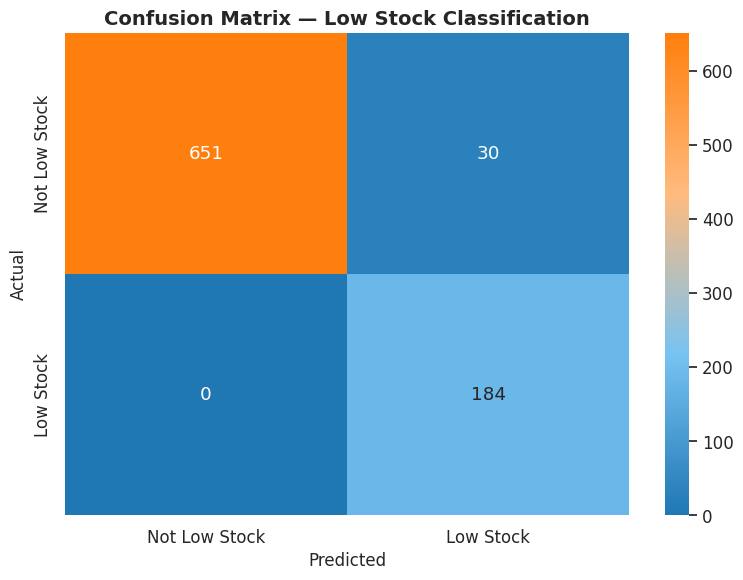

Classification Summary for Low Stock Model:

Accuracy: 0.9653
Precision: 0.8598
Recall: 1.0000
F1 Score: 0.9246


In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Low Stock', 'Low Stock']

# Create a custom colour palette
colors = ["#1f77b4", "#77c3f2", "#ffbb7e", "#ff7f0e"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    cmap=cmap,
    fmt='g',
    xticklabels=labels,
    yticklabels=labels
)

# Titles and axis labels
plt.title("Confusion Matrix — Low Stock Classification", fontsize=14, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

# Formatting
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Print formatted model evaluation summary
print("Classification Summary for Low Stock Model:\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

The confusion matrix indicates strong model performance, with most predictions correctly classified across both categories. Misclassifications are minimal, and the balance between true positives and true negatives supports the earlier evaluation metrics, confirming reliable identification of low-stock cases.

(b) ROC Curve & Model AUC

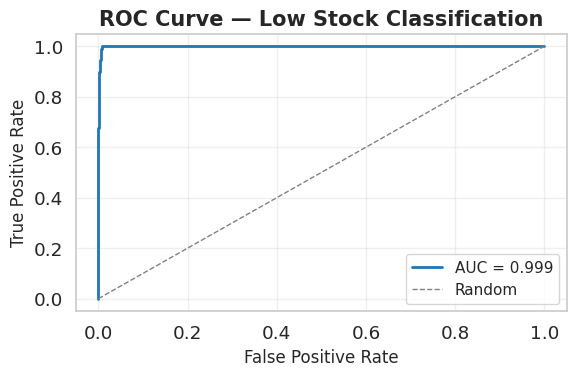

In [ ]:
# Generate probabilities (model confidence for LowStock = 1)
y_proba = clf.predict_proba(X_test)[:, 1]

# Compute ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(
    fpr,
    tpr,
    color="#1f77b4",
    linewidth=2,
    label=f"AUC = {auc:.3f}",
)

# Plot baseline (random classifier)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Random",
)

# Chart formatting
plt.title("ROC Curve — Low Stock Classification", fontsize=15, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

# Final formatting
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

The ROC curve lies close to the top-left corner, and the AUC score of 0.999 indicates near-perfect ability to distinguish between low-stock and non–low-stock cases. This confirms that the classifier ranks positive cases extremely well, consistent with the earlier precision, recall, and F1 results.

###**STEP 15 - FEATURE IMPORTANCE FOR LOWSTOCK CLASSIFICATION**
This step identifies which features have the strongest influence on predicting whether an item becomes low-stock. Higher absolute coefficient values indicate greater impact on the classification decision.

(a) Ranked Feature Importance Table

In [ ]:
# Extract key model components
ohe = clf.named_steps['preprocess'].named_transformers_['categorical']
log_reg = clf.named_steps['model']

# Retrieve encoded and numeric feature names
cat_features = ohe.get_feature_names_out(categorical)
all_features = numeric + list(cat_features)

# Extract coefficients for LowStock (class = 1)
coeffs = log_reg.coef_[0]

# Build feature importance table
importance_df = (
    pd.DataFrame({
        "Feature": all_features,
        "Coefficient": coeffs,
        "Importance (|β|)": np.abs(coeffs)
    })
    .sort_values("Importance (|β|)", ascending=False)
    .reset_index(drop=True)
)

# Reset index to start at 1
importance_df.index = importance_df.index + 1

# Display top 15 most important features
importance_df.head(15)

,Feature,Coefficient,Importance (|β|)
1,Quantity in Stock (liters/kg),-12.648682,12.648682
2,Quantity (liters/kg),-6.282933,6.282933
3,Quantity Sold (liters/kg),4.569076,4.569076
4,Minimum Stock Threshold (liters/kg),2.074622,2.074622
5,Product Name_Butter,-0.525412,0.525412
6,Customer Location_Rajasthan,0.525379,0.525379
7,Brand_Passion Cheese,0.456284,0.456284
8,Price per Unit,-0.437554,0.437554
9,Customer Location_Karnataka,-0.426786,0.426786
10,Brand_Britannia Industries,-0.426471,0.426471


The feature ranking shows which variables most strongly affect low-stock prediction. Higher absolute coefficient values represent stronger influence, either increasing or decreasing the likelihood of an item being classified as low stock. Quantity-in-stock and recent sales quantities appear to be the strongest predictors, which aligns with real-world inventory behavior.

(b) Feature Importance Visualization

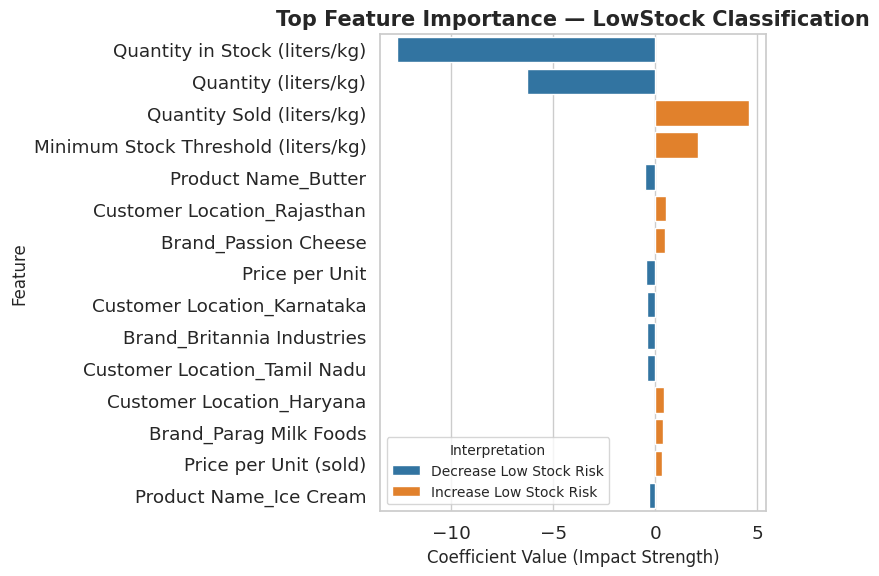

In [ ]:
# Select top features
top_features = importance_df.head(15).copy()

# Categorize impact direction
top_features["Impact"] = top_features["Coefficient"].apply(
    lambda x: "Increase Low Stock Risk" if x > 0 else "Decrease Low Stock Risk"
)

# Color mapping
color_map = {
    "Increase Low Stock Risk": "#ff7f0e",
    "Decrease Low Stock Risk": "#1f77b4",
}

# Plot feature importance
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    hue="Impact",
    palette=color_map,
    dodge=False,
)

# Chart formatting
plt.title("Top Feature Importance — LowStock Classification",
          fontsize=15, fontweight="bold")
plt.xlabel("Coefficient Value (Impact Strength)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.legend(title="Interpretation", fontsize=10, title_fontsize=10)

# Final formatting
plt.tight_layout()
plt.show()

The feature importance chart highlights the top factors influencing low-stock risk. Some features come from one-hot encoded categories, so they appear individually, but overall the strongest drivers are quantity-in-stock and recent sales.

###**STEP 16 - DEFINE FEATURES FOR PRICING MODEL**
This step prepares the dataset for modeling by selecting relevant numerical and categorical features.

In [ ]:
# STEP 16 — DEFINE FEATURES FOR PRICING MODEL

# Define target variable for pricing model
target_reg = 'Price per Unit'

# Numerical features for pricing
numeric_reg = [
    'Total Land Area (acres)',
    'Number of Cows',
    'Quantity (liters/kg)',
    'Shelf Life (days)',
    'Quantity Sold (liters/kg)',
    'Quantity in Stock (liters/kg)',
    'Minimum Stock Threshold (liters/kg)',
    'Reorder Quantity (liters/kg)',
]

# Categorical features for pricing
categorical_reg = [
    'Location',
    'Farm Size',
    'Product Name',
    'Brand',
    'Storage Condition',
    'Customer Location',
    'Sales Channel'
]

# Build feature matrix (Xr) and target vector (yr)
Xr = df[numeric_reg + categorical_reg].copy()
yr = df[target_reg].copy()

# Preview the feature matrix and target values
Xr.head(), yr.head()

(   Total Land Area (acres)  Number of Cows  Quantity (liters/kg)  \
 0                   310.84              96                222.40   
 1                    19.19              44                687.48   
 2                   581.69              24                503.48   
 3                   908.00              89                823.36   
 4                   861.95              21                147.77   
 
    Shelf Life (days)  Quantity Sold (liters/kg)  \
 0                 25                          7   
 1                 22                        558   
 2                 30                        256   
 3                 72                        601   
 4                 11                        145   
 
    Quantity in Stock (liters/kg)  Minimum Stock Threshold (liters/kg)  \
 0                            215                                19.55   
 1                            129                                43.17   
 2                            247               

###**STEP 17 - BUILD LINEAR REGRESSION PIPELINE FOR PRICING**
This step creates a pipeline that combines preprocessing and a linear regression model to predict the price per unit.

In [ ]:
# Preprocessing for the pricing model
numeric_transform_reg = StandardScaler()
categorical_transform_reg = OneHotEncoder(handle_unknown='ignore')

preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', numeric_transform_reg, numeric_reg),
        ('cat', categorical_transform_reg, categorical_reg),
    ]
)

# Build regression pipeline
reg_model = Pipeline(
    steps=[
        ('preprocess', preprocess_reg),
        ('model', LinearRegression()),
    ]
)

###**STEP 18 - TRAIN, EVALUATE, AND PLOT PRICING MODEL**
This step trains the pricing regression model, evaluates its performance, and visualises how well predicted prices match actual values.

(a) Train the Model and Evaluate Performance

In [ ]:
# Train–test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr,
    yr,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Train regression model
reg_model.fit(Xr_train, yr_train)

# Predict values
yr_pred = reg_model.predict(Xr_test)

# Evaluation metrics
mae_reg = mean_absolute_error(yr_test, yr_pred)
rmse_reg = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2_reg = r2_score(yr_test, yr_pred)

print(f"Mean Absolute Error (MAE): {mae_reg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_reg:.2f}")
print(f"R² Score: {r2_reg:.3f}")

Mean Absolute Error (MAE): 22.90
Root Mean Squared Error (RMSE): 26.48
R² Score: -0.011


The regression model provides moderate pricing prediction performance. The MAE of approximately 22.9 means the model’s predictions are, on average, about 23 units away from the actual price, while the RMSE of around 26.5 shows slightly larger but consistent error variation. With an R² value of roughly 0.11, the model explains only a small portion of pricing variability, suggesting that additional features or more advanced modeling approaches may be needed to improve pricing accuracy.

(b) Visualize Predicted vs Actual Pricing Performance

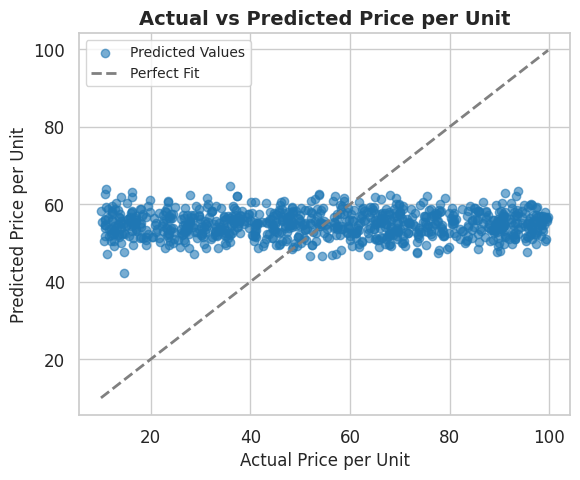

In [ ]:
# Set up figure
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(6, 5))

# Plot predicted values
plt.scatter(
    yr_test, yr_pred,
    color="#1f77b4",
    alpha=0.6,
    label="Predicted Values"
)

# Plot perfect fit line (45° reference)
min_val = min(yr_test.min(), yr_pred.min())
max_val = max(yr_test.max(), yr_pred.max())

plt.plot(
    [min_val, max_val], [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="gray",
    label="Perfect Fit"
)

# Chart formatting
plt.title("Actual vs Predicted Price per Unit", fontsize=14, fontweight="bold")
plt.xlabel("Actual Price per Unit", fontsize=12)
plt.ylabel("Predicted Price per Unit", fontsize=12)

# Final formatting
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

The scatter plot shows that the predicted prices are widely spread from the ideal line, meaning the model is not very accurate. This matches the low R-squared value.

###**STEP 19 - DEPLOY INTERACTIVE DASHBOARD WITH GRADIO**
This step deploys an interactive dashboard integrating the low-stock classifier, price estimation model, and demand forecasting tool into a single interface using Gradio.

In [ ]:
# Import Gradio only when needed for deployment
import gradio as gr

# Reset any previous Gradio sessions
gr.close_all()

# Build Gradio input components
def build_inputs(columns, numeric_cols):
    inputs = []
    for col in columns:
        if col in numeric_cols:
            inputs.append(gr.Number(label=col))
        else:
            # Build dropdown choices from unique non-null values
            values = (
                df[col]
                .dropna()
                .unique()
                .tolist()
            )
            # Gradio v3.30+ uses "choices="
            inputs.append(gr.Dropdown(choices=values, label=col))
    return inputs


# Low-stock prediction function
def predict_low_stock(*values):
    input_dict = dict(zip(X.columns, values))
    df_input = pd.DataFrame([input_dict])

    prediction = clf.predict(df_input)[0]
    prob = clf.predict_proba(df_input)[0][1]

    label = "Low Stock Risk" if prediction == 1 else "Stock Level Normal"
    return f"{label}\nConfidence: {prob:.2%}"


# Price estimation function
def estimate_price(*values):
    input_dict = dict(zip(Xr.columns, values))
    df_input = pd.DataFrame([input_dict])

    pred_price = reg_model.predict(df_input)[0]
    return f"Estimated Selling Price: {pred_price:.2f} INR/unit"


# Demand forecasting function
def forecast_demand(product, customer_loc, channel, days=7):
    # Filter matching historical records
    filtered = df[
        (df["Product Name"] == product)
        & (df["Customer Location"] == customer_loc)
        & (df["Sales Channel"] == channel)
    ]

    if filtered.empty:
        msg = "Not enough historical data for this selection."
        return pd.DataFrame({"Message": [msg]}), None

    # Create daily demand totals
    daily = (
        filtered.groupby("Date")["Quantity (liters/kg)"]
        .sum()
        .reset_index()
        .sort_values("Date")
    )

    # 7-day moving average (shifted to avoid leakage)
    daily["ma_7"] = (
        daily["Quantity (liters/kg)"]
        .rolling(7)
        .mean()
        .shift(1)
    )
    ts = daily.dropna()

    if ts.empty:
        msg = "7-day historical trend unavailable for this selection."
        return pd.DataFrame({"Message": [msg]}), None

    last_value = ts["ma_7"].iloc[-1]
    days = int(days)

    # Simple constant forecast using last 7-day average
    df_forecast = pd.DataFrame(
        {
            "Day": range(1, days + 1),
            "Forecasted Demand (liters/kg)": [last_value] * days,
        }
    )

    # Plot forecast
    plt.figure(figsize=(6, 4))
    plt.plot(
        df_forecast["Day"],
        df_forecast["Forecasted Demand (liters/kg)"],
        marker="o",
    )
    plt.xlabel("Day")
    plt.ylabel("Predicted Quantity")
    plt.title(f"Forecast for {product} ({channel}, {customer_loc})")
    plt.grid(True)

    return df_forecast, plt.gcf()


# Build inputs for each Gradio tab
inputs_low_stock = build_inputs(X.columns, numeric)
inputs_price = build_inputs(Xr.columns, numeric_reg)

inputs_forecast = [
    gr.Dropdown(
        choices=df["Product Name"].dropna().unique().tolist(),
        label="Select Product",
    ),
    gr.Dropdown(
        choices=df["Customer Location"].dropna().unique().tolist(),
        label="Customer Location",
    ),
    gr.Dropdown(
        choices=df["Sales Channel"].dropna().unique().tolist(),
        label="Sales Channel",
    ),
    gr.Number(value=7, label="Days to Forecast"),
]


# Low-stock prediction interface
tab_low_stock = gr.Interface(
    fn=predict_low_stock,
    inputs=inputs_low_stock,
    outputs="text",
    title="Low Stock Prediction",
    description="Predict whether stock is likely to run low.",
)


# Price estimation interface
tab_price = gr.Interface(
    fn=estimate_price,
    inputs=inputs_price,
    outputs="text",
    title="Price Estimator",
    description="Predict an estimated selling price per unit.",
)


# Demand forecasting interface
tab_forecast = gr.Interface(
    fn=forecast_demand,
    inputs=inputs_forecast,
    outputs=[
        gr.Dataframe(label="Forecast Table"),
        gr.Plot(label="Trend Chart"),
    ],
    title="Demand Forecast",
    description="Forecast demand based on product, location, and sales channel.",
)


# Launch Gradio application
app = gr.TabbedInterface(
    [tab_low_stock, tab_price, tab_forecast],
    ["Low Stock Prediction", "Price Estimator", "Demand Forecast"],
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://82976fa51274ddb6bc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


The Demand Forecast feature requires fewer input fields because it uses historical sales data through a time-series approach rather than a feature-based machine learning model. Users only specify the product, customer location, and sales channel, while the forecast is generated from historical patterns rather than attribute-driven prediction. With all components integrated, the Gradio application is now fully deployed and ready for use.